In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Import backtest module
from backtest import (
    backtest,
    summary_stats,
    compare_strategies,
    plot_backtest_results,
    drawdown_curve,
    max_drawdown,
    annualized_return,
    annualized_vol,
    sharpe_ratio,
)


In [12]:
CONFIG = {
    # Paths
    "earnings_path"   : "/Users/noah/Documents/Nova SBE/PMC/earningssurprise_S&Pall.xlsx",
    "earnings_sheet"  : "Data",
    "prices_path"     : "/Users/noah/Documents/Nova SBE/PMC/S&P_dailyprices_clean.csv",

    # SUE parameters
    "sue_window_q"    : 8,
    "sue_thresh_long" : 1.5,
    "sue_thresh_short": -1.5,

    # Z-score parameters
    "z_window_q"      : 8,
    "z_thresh_long"   : 1.0,
    "z_thresh_short"  : -1.0,

    # Holding periods (business days)
    "entry_lag_bdays"    : 1,
    "holding_long_bdays" : 7,
    "holding_short_bdays": 3,

    # Long-anchored overlay parameters
    "min_longs_for_shorts": 3,

    # Position concentration cap
    "max_weight_long"  : 0.20,
    "max_weight_short" : 0.20,

    # Backtest start
    "start_date"      : "2015-01-01",
}

In [14]:
def load_earnings(config: dict) -> pd.DataFrame:
    """
    Load and clean earnings data.

    - Reads EPS actual/estimate and computes percentage surprise.
    - Filters out technical issues (NaN, inf, extreme surprises).
    - Sorts by Security and AnnouncementDate.
    """
    df = pd.read_excel(config["earnings_path"], sheet_name=config["earnings_sheet"])
    df = df[["Security", "AnnouncementDate", "EPS_Actual", "EPS_Estimate"]].copy()

    df["AnnouncementDate"] = pd.to_datetime(df["AnnouncementDate"], dayfirst=True)
    df["EPS_Actual"]       = pd.to_numeric(df["EPS_Actual"], errors="coerce")
    df["EPS_Estimate"]     = pd.to_numeric(df["EPS_Estimate"], errors="coerce")

    df["Surprise_pct"] = (df["EPS_Actual"] - df["EPS_Estimate"]) / df["EPS_Estimate"].abs()

    mask_bad = (
        df["Surprise_pct"].isna() |
        np.isinf(df["Surprise_pct"]) |
        (df["Surprise_pct"].abs() > 5)
    )
    df.loc[mask_bad, "Surprise_pct"] = np.nan

    df = df.sort_values(["Security", "AnnouncementDate"]).reset_index(drop=True)
    return df

def load_prices(config: dict) -> pd.DataFrame:
    """
    Load daily price data and ensure a clean, sorted DateTime index.
    """
    prices = pd.read_csv(config["prices_path"], index_col=0)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.sort_index()
    return prices


earnings = load_earnings(CONFIG)
prices   = load_prices(CONFIG)

print(f"Earnings: {len(earnings)} rows, {earnings['Security'].nunique()} securities")
print(f"Prices:   {prices.shape[0]} days, {prices.shape[1]} tickers")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")


Earnings: 38626 rows, 503 securities
Prices:   5325 days, 497 tickers
Date range: 2005-01-03 to 2026-03-04


In [16]:
def compute_sue(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Compute Standardized Unexpected Earnings (SUE):

    - Forecast_Error = EPS_Actual - EPS_Estimate
    - SUE = Forecast_Error / rolling std of past forecast errors (per security)
    - Uses a rolling window over past quarters (sue_window_q).
    """
    df = df.copy()
    df["Forecast_Error"] = df["EPS_Actual"] - df["EPS_Estimate"]
    df["FE_shift"] = df.groupby("Security")["Forecast_Error"].shift(1)
    df["FE_std"] = df.groupby("Security")["FE_shift"].transform(
        lambda x: x.rolling(config["sue_window_q"], min_periods=4).std()
    )
    df["SUE"] = df["Forecast_Error"] / df["FE_std"].replace(0, np.nan)
    return df


def compute_zscore(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Compute Z-Score of percentage surprise per security:

    - Surprise_pct is shifted by 1 to avoid look-ahead.
    - Rolling mean/std over z_window_q quarters.
    - Z_Score = (Surprise_pct - roll_mean) / roll_std
    """
    df = df.copy()
    df["roll_mean"] = df.groupby("Security")["Surprise_pct"].transform(
        lambda x: x.shift(1).rolling(config["z_window_q"], min_periods=4).mean()
    )
    df["roll_std"] = df.groupby("Security")["Surprise_pct"].transform(
        lambda x: x.shift(1).rolling(config["z_window_q"], min_periods=4).std()
    )
    df["Z_Score"] = (df["Surprise_pct"] - df["roll_mean"]) / df["roll_std"].replace(0, np.nan)
    return df


def compute_signals(df, config):
    """
    - Long if SUE > sue_thresh_long AND Z_Score > z_thresh_long
    - Short if SUE < sue_thresh_short AND Z_Score < z_thresh_short
    - Otherwise: no position (Signal = 0)
    """
    df = df.copy()
    long_cond  = (df["SUE"] > config["sue_thresh_long"]) & (df["Z_Score"] > config["z_thresh_long"])
    short_cond = (df["SUE"] < config["sue_thresh_short"]) & (df["Z_Score"] < config["z_thresh_short"])
    df["Signal"] = np.where(long_cond, 1, np.where(short_cond, -1, 0))
    return df


earnings = compute_sue(earnings, CONFIG)
earnings = compute_zscore(earnings, CONFIG)
earnings = compute_signals(earnings, CONFIG)

signal_counts = earnings["Signal"].value_counts()
print("Signal distribution:")
print(f"  Long  (+1): {signal_counts.get(1, 0)}")
print(f"  Short (-1): {signal_counts.get(-1, 0)}")
print(f"  Flat   (0): {signal_counts.get(0, 0)}")

Signal distribution:
  Long  (+1): 2902
  Short (-1): 2809
  Flat   (0): 32915


In [17]:
def add_entry_exit(df, config):
    """
    Add entry and exit dates with asymmetric holding periods:

    - Entry_Date = AnnouncementDate + entry_lag_bdays
    - Longs: Exit_Date = Entry_Date + holding_long_bdays
    - Shorts: Exit_Date = Entry_Date + holding_short_bdays

    Only non-zero signals are kept.
    """
    df = df[df["Signal"] != 0].copy()
    df["Entry_Date"] = df["AnnouncementDate"] + pd.offsets.BDay(config["entry_lag_bdays"])

    is_long  = df["Signal"] == 1
    is_short = df["Signal"] == -1

    df["Exit_Date"] = pd.NaT
    df.loc[is_long,  "Exit_Date"] = df.loc[is_long,  "Entry_Date"] + pd.offsets.BDay(config["holding_long_bdays"])
    df.loc[is_short, "Exit_Date"] = df.loc[is_short, "Entry_Date"] + pd.offsets.BDay(config["holding_short_bdays"])
    return df


def build_signal_matrix(events, config):
    """
    Expand event-level signals into a daily signal matrix:

    - Rows: business days
    - Columns: tickers
    - Values: -1 (short), 0 (flat), +1 (long)
    - Exit date is exclusive: [Entry_Date, Exit_Date)
    """
    active = events[events["Entry_Date"] >= config["start_date"]].copy()
    if active.empty:
        raise ValueError("No active events after start_date.")

    tickers = sorted(active["Security"].unique())
    days    = pd.bdate_range(active["Entry_Date"].min(), active["Exit_Date"].max())

    ticker_idx = {t: i for i, t in enumerate(tickers)}
    day_idx    = {d: i for i, d in enumerate(days)}

    mat = np.zeros((len(days), len(tickers)), dtype=np.int8)

    for _, row in active.iterrows():
        t  = ticker_idx[row["Security"]]
        d0 = day_idx.get(row["Entry_Date"])
        d1 = day_idx.get(row["Exit_Date"])
        if d0 is not None and d1 is not None:
            mat[d0:d1, t] = row["Signal"]

    return pd.DataFrame(mat, index=days, columns=tickers)


events = add_entry_exit(earnings, CONFIG)
sigmat = build_signal_matrix(events, CONFIG)

print(f"Signal matrix: {sigmat.shape[0]} days × {sigmat.shape[1]} tickers")
print(f"Date range: {sigmat.index.min().date()} to {sigmat.index.max().date()}")


def construct_portfolio(sig, prices, config):
    """
    Long-anchored 50/50 portfolio with position cap.
    Equal-weight within each book
        - If at least x long(s) exists:
        * Longs get +50% exposure (equal-weighted)
        * Shorts get -50% exposure (equal-weighted)
        - If no longs exist: flat
        - Shorts only allowed when n_long >= min_longs_for_shorts
    Position cap (NEW):
        - Each long name is capped at max_weight_long of total portfolio
        - Each short name is capped at max_weight_short of total portfolio
        - Excess weight goes to cash (total book exposure shrinks)
        - This means on days with few signals, exposure is reduced rather
        than concentrating into a handful of names
    
    Returns dict with all return series and diagnostics.
    """
    returns = prices.pct_change()

    common_dates   = sig.index.intersection(returns.index)
    common_tickers = sig.columns.intersection(returns.columns)

    sig = sig.loc[common_dates, common_tickers]
    ret = returns.loc[common_dates, common_tickers]

    long_mask_raw  = sig == 1
    short_mask_raw = sig == -1

    n_long  = long_mask_raw.sum(axis=1)
    n_short = short_mask_raw.sum(axis=1)

    # Uncapped weights
    n_long_safe = n_long.replace(0, np.nan)
    long_w_uncap = long_mask_raw.div(n_long_safe, axis=0).fillna(0) * 0.5

    min_longs = config.get("min_longs_for_shorts", 1)
    allow_shorts_day = n_long >= min_longs

    short_mask = short_mask_raw & allow_shorts_day.values[:, None]
    short_mask = short_mask & (n_long > 0).values[:, None]

    n_short_eff = short_mask.sum(axis=1)
    n_short_safe = n_short_eff.replace(0, np.nan)

    short_w_uncap = short_mask.div(n_short_safe, axis=0).fillna(0) * -0.5

    # Uncapped portfolio return
    port_ret_uncap = (ret * (long_w_uncap + short_w_uncap)).sum(axis=1)

    # Apply position cap
    max_w_long  = config.get("max_weight_long",  0.20)
    max_w_short = config.get("max_weight_short", 0.20)

    long_w  = long_w_uncap.clip(upper=max_w_long)
    short_w = short_w_uncap.clip(lower=-max_w_short)

    long_exposure  = long_w.sum(axis=1)
    short_exposure = short_w.sum(axis=1)

    # Final returns
    port_ret  = (ret * (long_w + short_w)).sum(axis=1)
    long_ret  = (ret * long_w).sum(axis=1)
    short_ret = (ret * short_w).sum(axis=1)

    # Benchmark: equal-weight ALL tickers in price file (not just signal tickers)
    bench_ret = returns.loc[common_dates].mean(axis=1)

    return {
        "port_ret":       port_ret,
        "port_ret_uncap": port_ret_uncap,
        "long_ret":       long_ret,
        "short_ret":      short_ret,
        "bench_ret":      bench_ret,
        "n_long":         n_long,
        "n_short_eff":    n_short_eff,
        "long_exposure":  long_exposure,
        "short_exposure":  short_exposure,
    }


results = construct_portfolio(sigmat, prices, CONFIG)

# Unpack for convenience
port_ret       = results["port_ret"]
port_ret_uncap = results["port_ret_uncap"]
long_ret       = results["long_ret"]
short_ret      = results["short_ret"]
bench_ret      = results["bench_ret"]

print("Portfolio constructed successfully.")
print(f"Days: {len(port_ret)}, from {port_ret.index.min().date()} to {port_ret.index.max().date()}")

Signal matrix: 2910 days × 491 tickers
Date range: 2015-01-16 to 2026-03-12
Portfolio constructed successfully.
Days: 2798, from 2015-01-16 to 2026-03-04


/var/folders/bz/fj16p7yn2qz3mm_zjc099_6w0000gn/T/ipykernel_3860/4218329366.py:79: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()


---
## 6. Backtest Module Integration

**Important note:** Our strategy already computes weighted portfolio returns internally
(with position caps, long-anchored overlay, etc.). The `backtest()` function expects
raw long/short returns and applies its own simple `long - short` calculation.

So we use two approaches:
- **`backtest()`** → feed it the raw long-leg and inverted short-leg returns for its portfolio value tracking
- **`summary_stats()` / `compare_strategies()`** → feed directly with our pre-computed return series

### 6a. Run `backtest()` for portfolio value tracking

The `backtest()` function computes `strategy_returns = long_returns - short_returns`.

Our `short_ret` is already negative when shorts profit (sign-flipped by negative weights).
So we pass `-short_ret` as `short_returns` so the subtraction works correctly:
`long_ret - (-short_ret) = long_ret + short_ret = port_ret` ✓

In [18]:
# Run backtest() for portfolio value tracking and visualization
bt_results = backtest(
    long_returns  = long_ret,
    short_returns = -short_ret,  # flip sign: backtest() does long - short internally
    initial_capital = 100000.0,
    leverage = 1.0
)

print(bt_results.head(10))
print(f"\nFinal portfolio value: ${bt_results['portfolio_value'].iloc[-1]:,.0f}")

              long_value   short_value  portfolio_value   returns  \
date                                                                
2015-01-16  50071.844772  50000.000000    100143.689544  0.001437   
2015-01-20  49972.946089  50000.000000     99945.892178 -0.001975   
2015-01-21  51813.892293  50000.000000    103627.784587  0.036839   
2015-01-22  52539.107286  50935.646402    103139.035296 -0.004716   
2015-01-23  52380.831537  50758.081036    103187.875814  0.000474   
2015-01-26  52477.146651  50758.631584    103376.493016  0.001828   
2015-01-27  52204.830612  50635.460593    103090.902099 -0.002763   
2015-01-28  51991.878603  50427.378984    103094.019772  0.000030   
2015-01-29  51945.401561  49617.866790    104656.832373  0.015159   
2015-01-30  51709.260952  49514.358606    104399.394194 -0.002460   

            cumulative_returns  
date                            
2015-01-16            1.001437  
2015-01-20            0.999459  
2015-01-21            1.036278  
2015-0

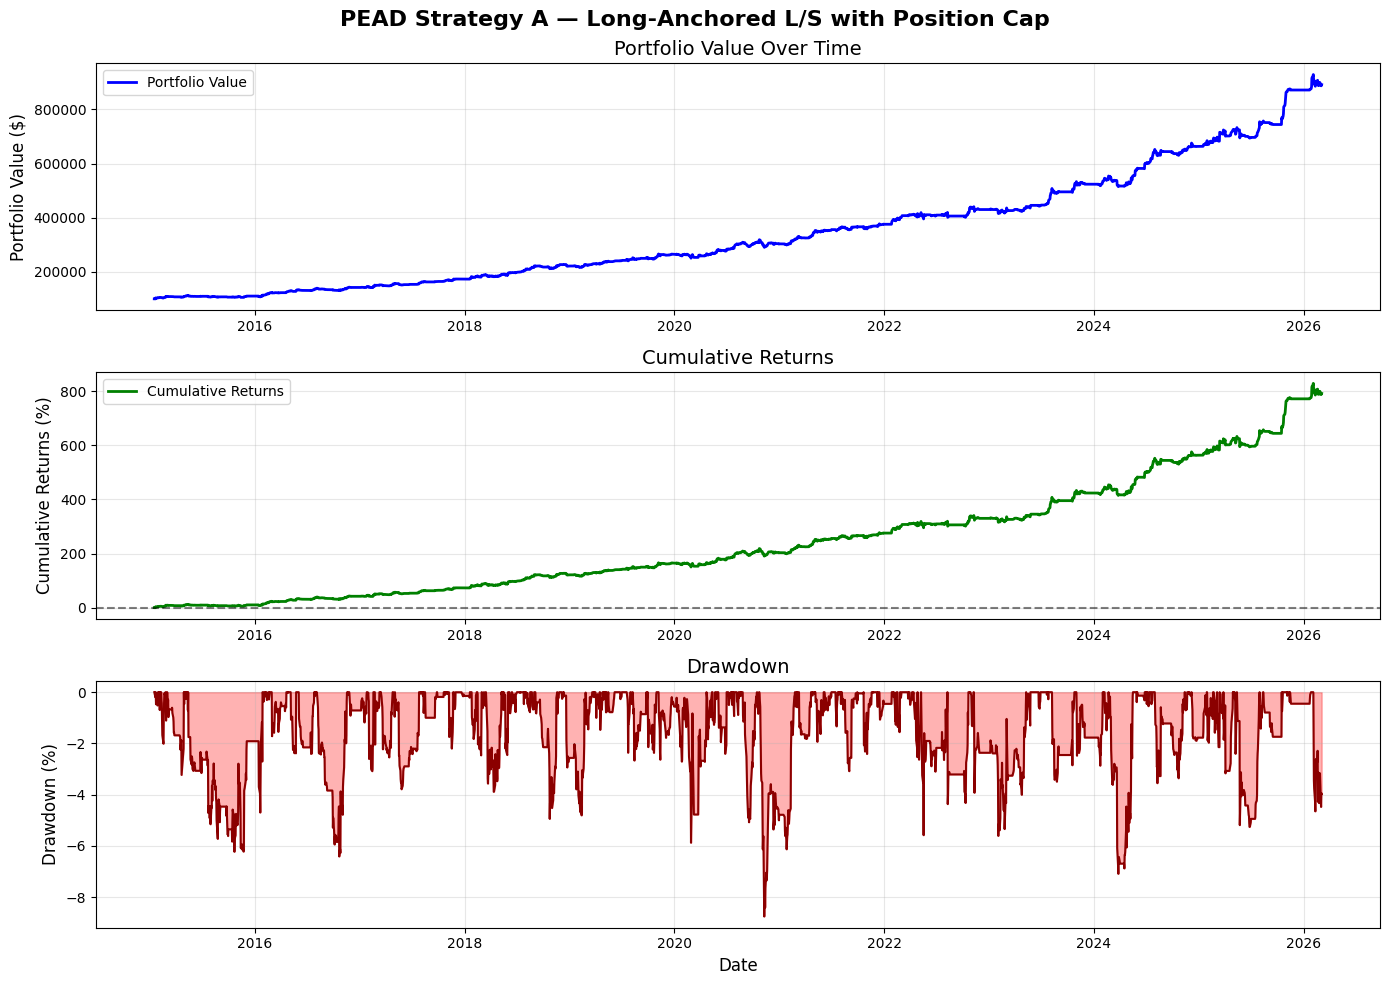

In [19]:
fig = plot_backtest_results(
    bt_results,
    title="PEAD Strategy A — Long-Anchored L/S with Position Cap"
)
plt.show()

In [20]:
# Summary stats for the L/S portfolio
strat_stats = summary_stats(port_ret, risk_free_rate=0.02)

print("=" * 50)
print("STRATEGY SUMMARY STATISTICS")
print("=" * 50)
for key, val in strat_stats.items():
    if isinstance(val, float):
        if 'Return' in key or 'Volatility' in key or 'Drawdown' in key or 'Rate' in key or 'Win' in key or 'Day' in key or 'Loss' in key:
            print(f"  {key:25s}: {val*100:8.2f}%")
        else:
            print(f"  {key:25s}: {val:8.2f}")
    else:
        print(f"  {key:25s}: {val}")

STRATEGY SUMMARY STATISTICS
  Total Return             :   791.71%
  Annualized Return        :    21.78%
  Annualized Volatility    :    10.03%
  Sharpe Ratio             :     1.97
  Max Drawdown             :    -8.76%
  Win Rate                 :    39.92%
  Avg Win                  :     0.54%
  Avg Loss                 :    -0.45%
  Best Day                 :     4.81%
  Worst Day                :    -4.37%
  Total Days               : 2798


In [21]:
# Compare all legs + benchmark using the backtest module
comparison = compare_strategies(
    strategies={
        "L/S Capped":        port_ret,
        "L/S Uncapped":      port_ret_uncap,
        "Long Book (capped)": long_ret,
        "Short Book (capped)": short_ret,
        "Benchmark (EW S&P)": bench_ret,
    },
    risk_free_rate=0.02
)

# Display nicely
display_cols = ["Annualized Return", "Annualized Volatility", "Sharpe Ratio",
                "Max Drawdown", "Win Rate", "Best Day", "Worst Day", "Total Days"]

print(comparison[display_cols].round(2).to_string())

                     Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown  Win Rate  Best Day  Worst Day  Total Days
L/S Capped                       21.78                  10.03          1.97         -8.76     39.92      4.81      -4.37      2798.0
L/S Uncapped                     22.03                  14.11          1.42        -18.48     39.67      7.82      -6.67      2798.0
Long Book (capped)               14.97                   8.30          1.56         -8.45     38.67      4.81      -4.11      2798.0
Short Book (capped)               5.75                   8.09          0.46        -14.99     16.98      3.26      -5.47      2798.0
Benchmark (EW S&P)               16.80                  18.40          0.80        -38.30     55.36     11.28     -12.83      2798.0


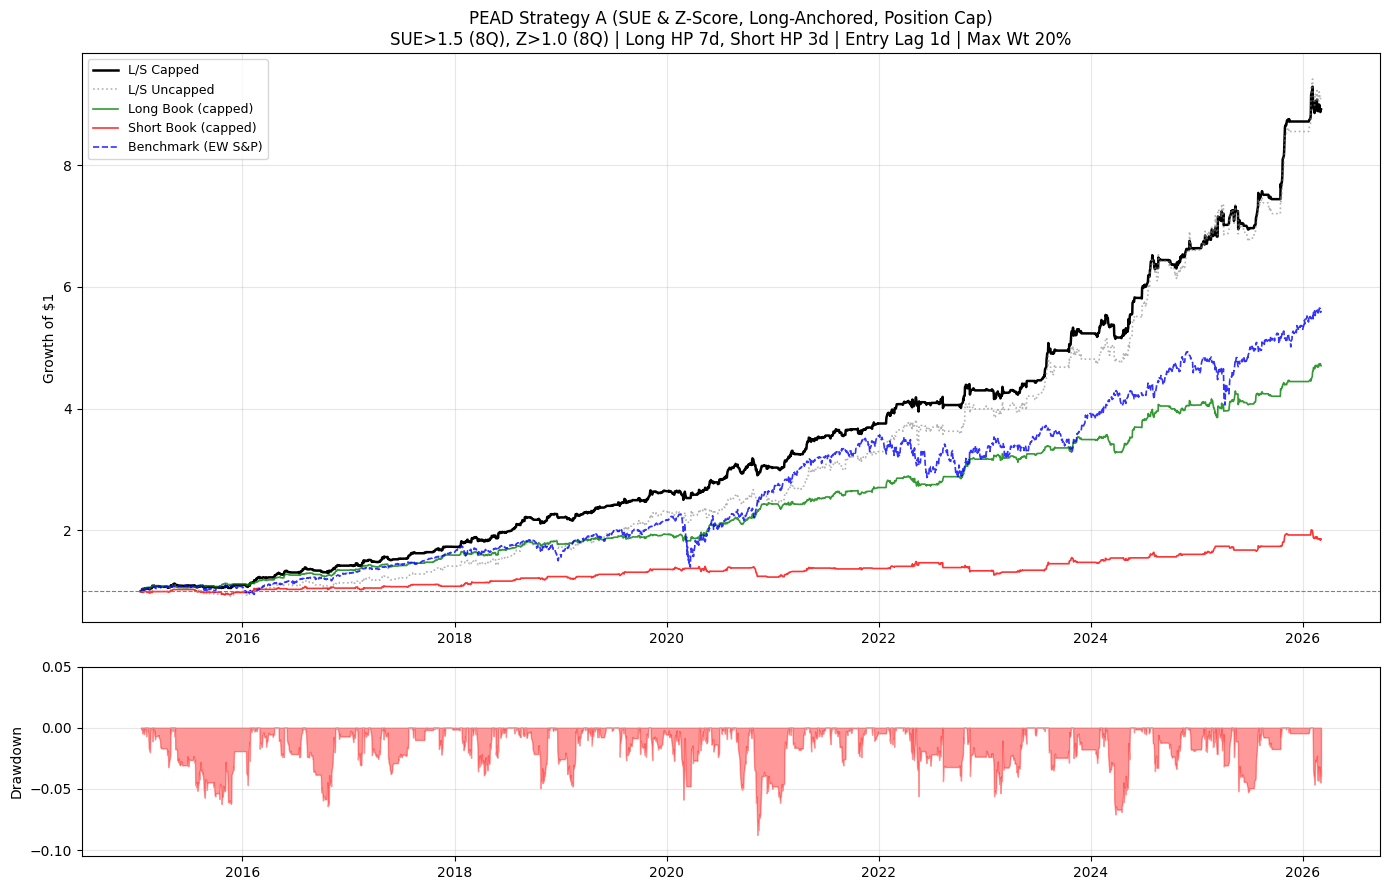

In [22]:
cum_strat = (1 + port_ret.fillna(0)).cumprod()
cum_uncap = (1 + port_ret_uncap.fillna(0)).cumprod()
cum_long  = (1 + long_ret.fillna(0)).cumprod()
cum_short = (1 + short_ret.fillna(0)).cumprod()
cum_bench = (1 + bench_ret.fillna(0)).cumprod()

dd = drawdown_curve(port_ret)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [3, 1]})

ax = axes[0]
ax.plot(cum_strat, label="L/S Capped",          color="black", lw=1.8)
ax.plot(cum_uncap, label="L/S Uncapped",         color="gray",  lw=1.2, alpha=0.6, ls=":")
ax.plot(cum_long,  label="Long Book (capped)",   color="green", lw=1.2, alpha=0.8)
ax.plot(cum_short, label="Short Book (capped)",  color="red",   lw=1.2, alpha=0.8)
ax.plot(cum_bench, label="Benchmark (EW S&P)",   color="blue",  lw=1.2, alpha=0.8, ls="--")
ax.axhline(1, color="gray", lw=0.8, ls="--")
ax.set_title(
    f"PEAD Strategy A (SUE & Z-Score, Long-Anchored, Position Cap)\n"
    f"SUE>{CONFIG['sue_thresh_long']} ({CONFIG['sue_window_q']}Q), "
    f"Z>{CONFIG['z_thresh_long']} ({CONFIG['z_window_q']}Q) | "
    f"Long HP {CONFIG['holding_long_bdays']}d, Short HP {CONFIG['holding_short_bdays']}d | "
    f"Entry Lag {CONFIG['entry_lag_bdays']}d | Max Wt {CONFIG['max_weight_long']*100:.0f}%",
    fontsize=12
)
ax.set_ylabel("Growth of $1")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.fill_between(dd.index, dd, 0, color="red", alpha=0.4)
ax2.set_ylabel("Drawdown")
ax2.set_ylim(dd.min() * 1.2, 0.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
n_long      = results["n_long"]
n_short_eff = results["n_short_eff"]
long_exp    = results["long_exposure"]
short_exp   = results["short_exposure"]

# Effective overlap (after overlay)
eff_hedged     = ((n_long > 0) & (n_short_eff > 0)).mean() * 100
eff_long_only  = ((n_long > 0) & (n_short_eff == 0)).mean() * 100
eff_short_only = ((n_short_eff > 0) & (n_long == 0)).mean() * 100
eff_flat       = ((n_long == 0) & (n_short_eff == 0)).mean() * 100

print("=== Effective Overlap (after overlay + cap) ===")
print(f"Hedged days:      {eff_hedged:.1f}%")
print(f"Long-only days:   {eff_long_only:.1f}%")
print(f"Short-only days:  {eff_short_only:.1f}%")
print(f"Flat days:        {eff_flat:.1f}%")

print(f"\n=== Exposure ===")
print(f"Avg long exposure:    {long_exp.mean()*100:.1f}%")
print(f"Avg short exposure:   {short_exp.abs().mean()*100:.1f}%")
print(f"Median long exposure: {long_exp.median()*100:.1f}%")
print(f"Median short exposure:{short_exp.abs().median()*100:.1f}%")

=== Effective Overlap (after overlay + cap) ===
Hedged days:      31.9%
Long-only days:   38.3%
Short-only days:  0.0%
Flat days:        29.8%

=== Exposure ===
Avg long exposure:    28.0%
Avg short exposure:   13.9%
Median long exposure: 20.0%
Median short exposure:0.0%


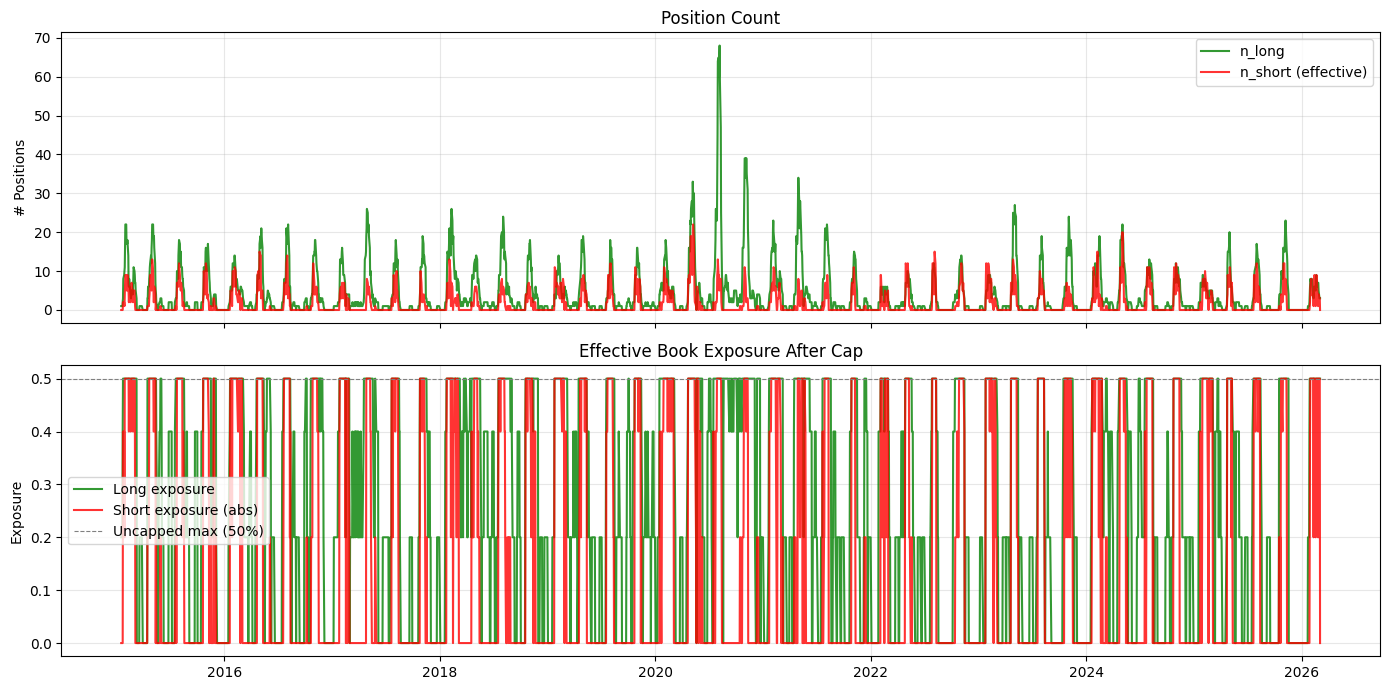

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(n_long.index, n_long, label="n_long", color="green", alpha=0.8)
axes[0].plot(n_short_eff.index, n_short_eff, label="n_short (effective)", color="red", alpha=0.8)
axes[0].set_title("Position Count")
axes[0].set_ylabel("# Positions")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(long_exp.index, long_exp, label="Long exposure", color="green", alpha=0.8)
axes[1].plot(short_exp.index, short_exp.abs(), label="Short exposure (abs)", color="red", alpha=0.8)
axes[1].axhline(0.50, color="gray", ls="--", lw=0.8, label="Uncapped max (50%)")
axes[1].set_title("Effective Book Exposure After Cap")
axes[1].set_ylabel("Exposure")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()